**Relatório de Avaliação e Acessibilidade Visual**

**1. Diagnóstico do Gráfico Original (Ranking de Pesquisadores)**
* **Contraste de Luminosidade:** O tom de azul uniforme apresentava pouca variação de brilho, dificultando a leitura caso impresso em escala de cinza ou visualizado por pessoas com daltonismo (protanopia/deuteranopia).
* **Uso do Cinza e Hierarquia:** Os eixos e linhas do gráfico usavam a cor preta padrão do sistema, gerando alto ruído visual e competindo diretamente com a atenção dedicada aos dados.
* **Poluição Visual:** Ausência de destaque intencional; todas as barras/pontos recebiam a mesma intensidade de cor sem direcionar o foco do leitor.

**2. Paleta Selecionada e Especificações**
* **Destaque Principal (Top 1):** `#0E4D92` (Azul Marinho - Alta saturação e forte contraste visual).
* **Demais Posições:** `#8FAADC` (Azul Suave - Saturação reduzida para atuar como contexto).
* **Elementos de Suporte (Eixos e Grades):** `#D9D9D9` e `#595959` (Cinza neutro para reduzir o ruído e organizar a estrutura).

**3. Justificativa das Melhorias Aplicadas**
* **Foco no Data-Ink Ratio:** O cinza atenuou elementos secundários (eixos e bordas), deixando a informação dos pesquisadores em evidência.
* **Acessibilidade:** A variação de luminosidade entre o líder e os demais dados garante leitura clara mesmo sob simulação de daltonismo ou impressão em preto e branco.

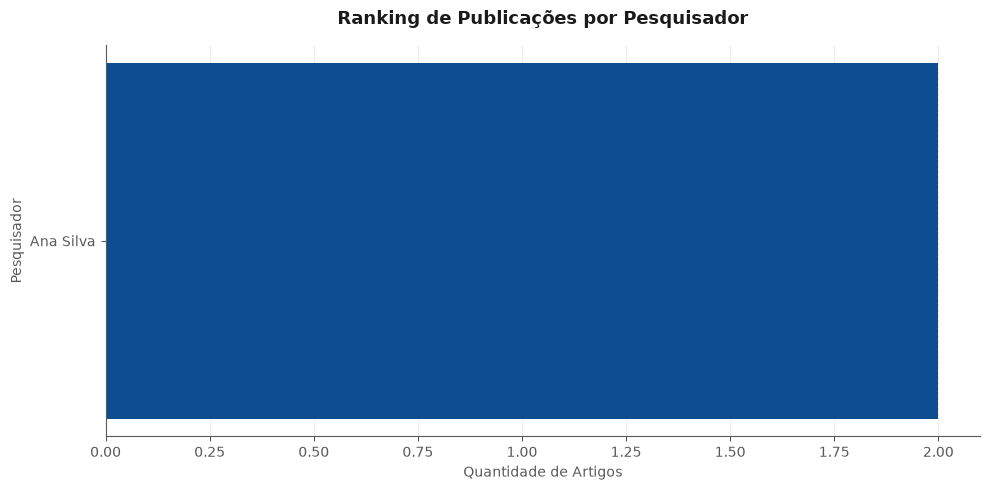

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# 1. Carrega os dados
caminho = (
    Path("artigos.parquet")
    if Path("artigos.parquet").exists()
    else Path("../data/exemplo/artigos.parquet")
)
df = pd.read_parquet(caminho)

col_autor = "pesquisador" if "pesquisador" in df.columns else "nome_completo"
ranking = df.groupby(col_autor).size().sort_values(ascending=True)

# 2. Configuração de cores acessíveis
cor_destaque = "#0E4D92"  # Azul escuro para o líder
cor_contexto = "#8FAADC"  # Azul suave para os demais
cor_elementos = "#595959"  # Cinza escuro para eixos/textos
cor_grade = "#E5E5E5"  # Cinza claro para linhas de fundo

# Mapeia cores: apenas o maior valor recebe o tom de destaque
cores = [
    cor_destaque if i == len(ranking) - 1 else cor_contexto
    for i in range(len(ranking))
]

# 3. Plotagem do gráfico otimizado
fig, ax = plt.subplots(figsize=(10, 5))

# Grade discreta de fundo
ax.set_axisbelow(True)
ax.xaxis.grid(True, color=cor_grade, linestyle="--", linewidth=0.7)

# Barras horizontais limpas
barras = ax.barh(ranking.index, ranking.values, color=cores, height=0.65)

# Ajuste fino de hierarquia visual nos eixos
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(cor_elementos)
ax.spines["bottom"].set_color(cor_elementos)
ax.tick_params(colors=cor_elementos)

# Título e Rótulos com foco visual
plt.title(
    "Ranking de Publicações por Pesquisador",
    fontsize=13,
    fontweight="bold",
    color="#1A1A1A",
    pad=15,
)
plt.xlabel("Quantidade de Artigos", fontsize=10, color=cor_elementos)
plt.ylabel("Pesquisador", fontsize=10, color=cor_elementos)

plt.tight_layout()
plt.show()